# Lokacje Moonwalk na mapie Księżyca — Mercator

Notatnik czyta te same dane co glob w Godocie: `godot/assets/moon/colonies.json`. Współrzędne kolonii są obecnie przybliżonymi pozycjami projektowymi, a nie pomiarami terenowymi.

Mapa używa sferycznego odwzorowania Mercatora. Bieguny są przycięte do ±85°, ponieważ Mercator nie ma skończonej wartości w ±90°.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

# Notatnik leży w <repo>/notebooks; uruchomienie z katalogu repo też działa.
ROOT = Path.cwd()
if not (ROOT / 'godot' / 'assets' / 'moon' / 'colonies.json').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'godot' / 'assets' / 'moon'

with (DATA / 'colonies.json').open(encoding='utf-8') as file:
    catalog = json.load(file)
locations = catalog['locations']
routes = catalog['routes']
print(f'Wczytano {len(locations)} lokalizacji i {len(routes)} tras z: {DATA}')

Wczytano 14 lokalizacji i 21 tras z: d:\projects\moonwalk\godot\assets\moon


In [2]:
MOON_RADIUS_KM = 1737.4
MERCATOR_LIMIT = 85.0

def mercator_y(latitude_deg):
    """Współrzędna Y sferycznego Mercatora dla szerokości w stopniach."""
    lat = np.clip(latitude_deg, -MERCATOR_LIMIT, MERCATOR_LIMIT)
    return np.log(np.tan(np.pi / 4 + np.deg2rad(lat) / 2))

def lunar_distance_km(a, b):
    """Odległość po wielkim kole na sferze Księżyca."""
    lat1, lon1 = map(math.radians, (a['latitude'], a['longitude']))
    lat2, lon2 = map(math.radians, (b['latitude'], b['longitude']))
    cosine = math.sin(lat1) * math.sin(lat2) + math.cos(lat1) * math.cos(lat2) * math.cos(lon1 - lon2)
    return MOON_RADIUS_KM * math.acos(np.clip(cosine, -1, 1))

by_name = {location['name']: location for location in locations}
for location in locations:
    location['mercator_x'] = location['longitude']
    location['mercator_y'] = float(mercator_y(location['latitude']))

print('Najbliższa para:', min((lunar_distance_km(a, b), a['name'], b['name'])
                              for i, a in enumerate(locations) for b in locations[i + 1:]))

Najbliższa para: (38.47692967965991, 'Silesia', 'Lubin Deep')


In [3]:
def equirectangular_to_mercator(image, max_latitude=MERCATOR_LIMIT, output_height=1200):
    """Próbkuje globalną albedo-mapę 2:1 na płótno Mercatora."""
    output_width = image.shape[1]
    y = np.linspace(mercator_y(max_latitude), mercator_y(-max_latitude), output_height)
    latitude = np.rad2deg(2 * np.arctan(np.exp(y)) - np.pi / 2)
    source_y = np.clip(((90 - latitude) / 180 * (image.shape[0] - 1)).round().astype(int), 0, image.shape[0] - 1)
    return image[source_y, :, ...]

albedo = plt.imread(DATA / 'albedo.jpg')
mercator_albedo = equirectangular_to_mercator(albedo)
print('Albedo:', albedo.shape, 'to Mercator:', mercator_albedo.shape)

Albedo: (2048, 4096, 3) to Mercator: (1200, 4096, 3)


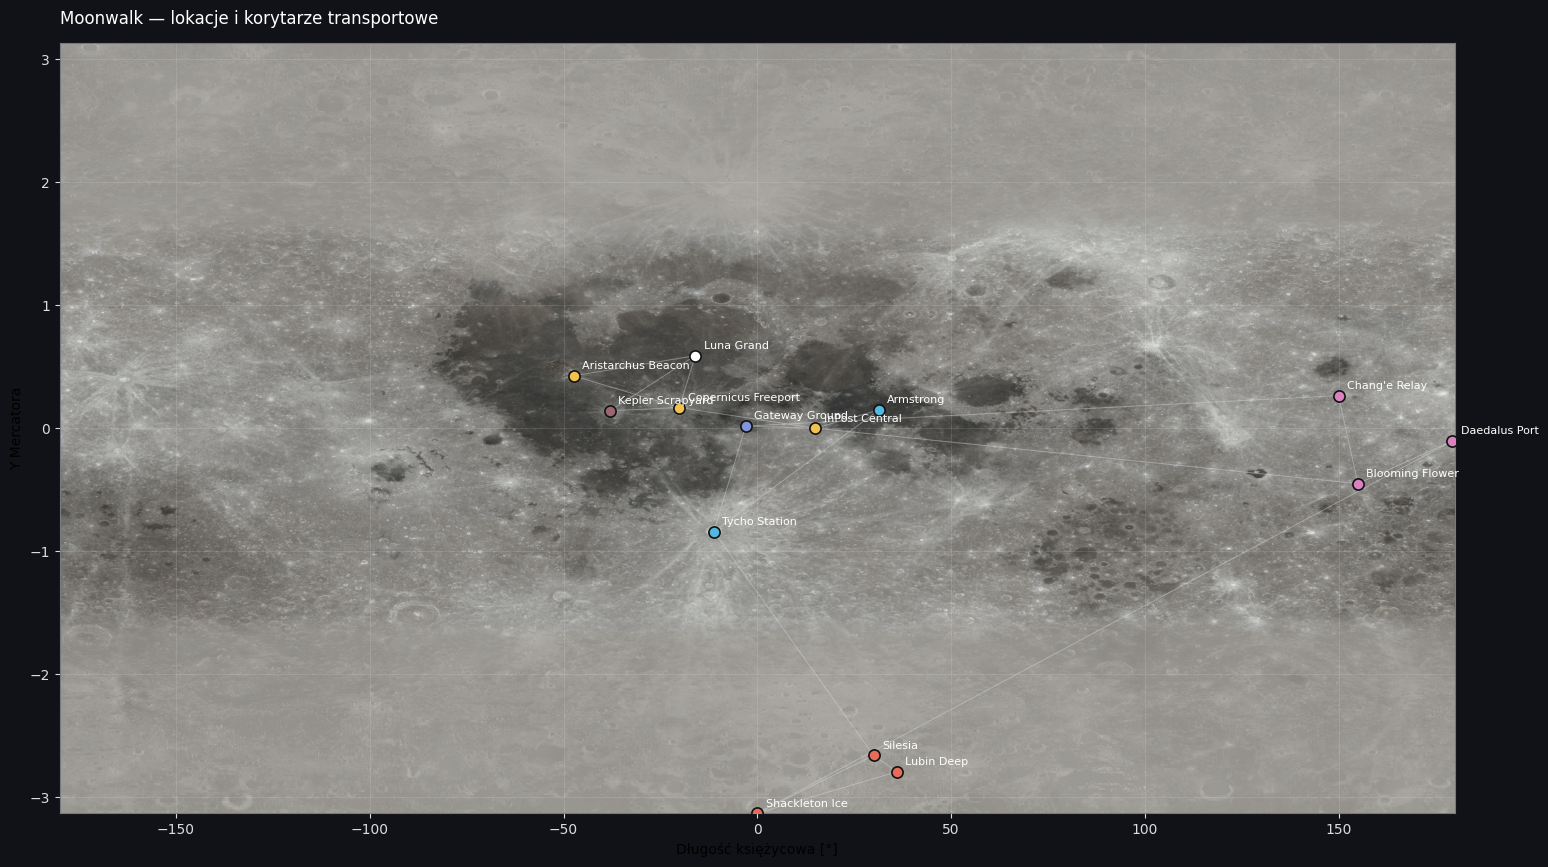

In [4]:
OWNER_COLORS = {
    'InPost Lunar': '#f2c14e',
    'Lunar Science Compact': '#53b8dd',
    'Silesian Union': '#e66b5b',
    'US Space Navy': '#8394d8',
    'Free Crater Brotherhood': '#9a6670',
    'Blooming Flower Authority': '#d982bf',
}

def draw_map(show_routes=True, label_size=8):
    fig, ax = plt.subplots(figsize=(18, 10), facecolor='#101217')
    ax.set_facecolor('#101217')
    ymax = mercator_y(MERCATOR_LIMIT)
    ax.imshow(mercator_albedo, extent=(-180, 180, -ymax, ymax), aspect='auto', alpha=0.9)

    if show_routes:
        for route in routes:
            a, b = by_name[route['a']], by_name[route['b']]
            # Trasy na mapie są orientacyjne; przy przejściu przez ±180° dzielimy linię.
            x1, x2 = a['mercator_x'], b['mercator_x']
            if abs(x2 - x1) > 180:
                if x1 < x2:
                    x1 += 360
                else:
                    x2 += 360
            ax.plot([x1, x2], [a['mercator_y'], b['mercator_y']], color='#d9dde1', alpha=0.42, linewidth=0.7, zorder=2)

    for location in locations:
        color = OWNER_COLORS.get(location['owner'], '#ffffff')
        ax.scatter(location['mercator_x'], location['mercator_y'], s=65, c=color, edgecolors='#111111', linewidths=1.2, zorder=4)
        ax.annotate(location['name'], (location['mercator_x'], location['mercator_y']),
                    xytext=(6, 5), textcoords='offset points', color='white', fontsize=label_size, zorder=5)

    ax.set(xlim=(-180, 180), ylim=(-ymax, ymax), xlabel='Długość księżycowa [°]', ylabel='Y Mercatora')
    ax.set_title('Moonwalk — lokacje i korytarze transportowe', color='white', loc='left', pad=14)
    ax.grid(color='white', alpha=0.13, linewidth=0.6)
    ax.tick_params(colors='#d9dde1')
    for spine in ax.spines.values():
        spine.set_color('#747b85')
    return fig, ax

fig, ax = draw_map()
plt.show()

In [ ]:
# Tabela najbliższych sąsiadów i porównanie odległości geograficznej z długością trasy.
import pandas as pd

nearest = []
for a in locations:
    distance, b = min((lunar_distance_km(a, b), b) for b in locations if b['name'] != a['name'])
    nearest.append({'lokacja': a['name'], 'najbliższa': b['name'], 'po łuku [km]': round(distance)})
display(pd.DataFrame(nearest).sort_values('po łuku [km]'))

route_rows = []
for route in routes:
    geodesic = lunar_distance_km(by_name[route['a']], by_name[route['b']])
    route_rows.append({
        'trasa': f"{route['a']} — {route['b']}",
        'środek': route['mode'],
        'projekt [km]': route['distance_km'],
        'po łuku [km]': round(geodesic),
        'różnica [km]': round(route['distance_km'] - geodesic),
    })
display(pd.DataFrame(route_rows).sort_values('projekt [km]', ascending=False))

In [ ]:
# Opcjonalne zapisanie mapy do artefaktów projektu.
output = ROOT / 'artifacts' / 'mapa_lokalizacji_mercator.png'
output.parent.mkdir(exist_ok=True)
fig, _ = draw_map(label_size=8)
fig.savefig(output, dpi=180, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.close(fig)
print(f'Zapisano: {output}')